# Benchmarking and statistics

A single seeded run (notebooks 1 and 2) is an illustration, never
evidence. This notebook runs three built-in algorithms across five seeds
on two BBOB problems, then applies part of `sezgi.stats.*` — the same
toolkit [Tutorial 8](../tutorials/08-comparing-algorithms.html) and
[Learn 5](../learn/05-comparing-algorithms-fairly.html) use — to the
results. Budgets and seed counts are kept deliberately small here so the
whole notebook runs in a couple of seconds; a real study needs many more
seeds and problems than this illustration uses.


## The grid: 3 algorithms x 2 problems x 5 seeds

`sezgi.run_experiment`'s TOML-grid surface (Tutorial 8) is the right tool
for a large sweep; for a small grid like this one, plain nested loops over
`.run()` calls are just as clear and keep every step visible:


In [1]:
import sezgi

algorithms = {
    "random_search": lambda: sezgi.RandomSearch(pop_size=20),
    "diff_evolution": lambda: sezgi.DifferentialEvolution(pop_size=20),
    "genetic_algo": lambda: sezgi.GeneticAlgorithm(pop_size=20),
}
problems = {
    "bbob_f1_sphere": sezgi.bbob(1, 5, 1),      # unimodal
    "bbob_f3_rastrigin": sezgi.bbob(3, 5, 1),   # multimodal, separable
}
budget = 400
seeds = range(5)

# gaps[problem_name][algo_name] = [gap_seed0, gap_seed1, ...]
gaps = {pname: {aname: [] for aname in algorithms} for pname in problems}

for pname, problem in problems.items():
    for aname, make_algo in algorithms.items():
        for seed in seeds:
            r = make_algo().run(problem, budget=budget, seed=seed)
            gaps[pname][aname].append(r.gap)

for pname in problems:
    for aname in algorithms:
        vals = gaps[pname][aname]
        mean = sum(vals) / len(vals)
        print(f"{pname:<20} {aname:<15} mean_gap={mean:.6g}")


bbob_f1_sphere       random_search   mean_gap=3.52985
bbob_f1_sphere       diff_evolution  mean_gap=0.30849
bbob_f1_sphere       genetic_algo    mean_gap=0.768279
bbob_f3_rastrigin    random_search   mean_gap=37.1302
bbob_f3_rastrigin    diff_evolution  mean_gap=15.9566
bbob_f3_rastrigin    genetic_algo    mean_gap=17.1991


## Friedman: are the three algorithms distinguishable at all?

`sezgi.stats.friedman(results)` takes a 2D matrix (rows = problems,
columns = algorithms) of one aggregated score per (problem, algorithm)
cell — here, the mean gap over the five seeds above — and returns a
rank-based test statistic plus each algorithm's mean rank (lower is
better):


In [2]:
algo_names = list(algorithms)
problem_names = list(problems)

matrix = [
    [sum(gaps[pname][aname]) / len(gaps[pname][aname]) for aname in algo_names]
    for pname in problem_names
]

friedman = sezgi.stats.friedman(matrix)
print(f"algorithms: {algo_names}")
print(f"problems:   {problem_names}")
print(f"friedman statistic={friedman['statistic']:.4g} p_value={friedman['p_value']:.4g}")
for name, rank in zip(algo_names, friedman["mean_ranks"]):
    print(f"  mean_rank[{name}] = {rank:.3g}")


algorithms: ['random_search', 'diff_evolution', 'genetic_algo']
problems:   ['bbob_f1_sphere', 'bbob_f3_rastrigin']
friedman statistic=4 p_value=0.1353
  mean_rank[random_search] = 3
  mean_rank[diff_evolution] = 1
  mean_rank[genetic_algo] = 2


Two problems is far too few blocks for this p-value to mean much on its
own — this is the mechanics of the test, not a claim about statistical
power. A real study runs the same grid over many more BBOB functions and
dimensions before reading anything into the p-value.


## Wilcoxon + Cliff's delta: one direct pairwise comparison

For a single, paired, two-algorithm comparison on one problem (rather
than the whole grid), `sezgi.stats.wilcoxon` takes matched per-seed
samples, and `sezgi.stats.cliffs_delta` reports a non-parametric effect
size for the same two samples (`stats.cliffs_magnitude` turns the number
into a qualitative label):


In [3]:
a = gaps["bbob_f1_sphere"]["diff_evolution"]
b = gaps["bbob_f1_sphere"]["random_search"]

w = sezgi.stats.wilcoxon(a, b)
delta = sezgi.stats.cliffs_delta(a, b)
magnitude = sezgi.stats.cliffs_magnitude(delta)

print(f"DifferentialEvolution vs RandomSearch on bbob_f1_sphere ({len(a)} paired seeds):")
print(f"  wilcoxon: p_value={w['p_value']:.4g} method={w['method']}")
print(f"  cliffs_delta={delta:.4g} ({magnitude})")


DifferentialEvolution vs RandomSearch on bbob_f1_sphere (5 paired seeds):
  wilcoxon: p_value=0.0625 method=exact
  cliffs_delta=-1 (large)


## One summary plot

A grouped bar chart of the mean gap per algorithm, one group per problem
— the same `gaps` dict computed above, no re-running:


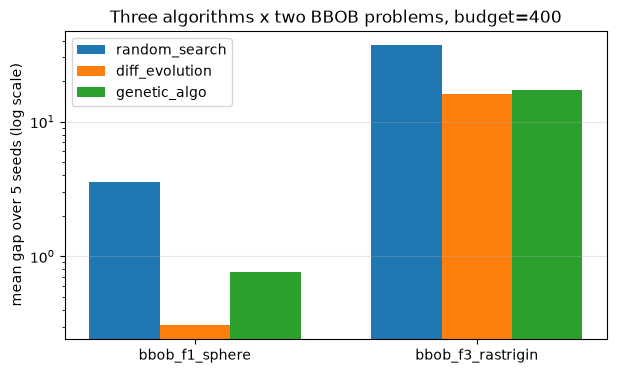

In [4]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(problem_names))
width = 0.25

fig, ax = plt.subplots(figsize=(7, 4))
for i, aname in enumerate(algo_names):
    means = [sum(gaps[pname][aname]) / len(gaps[pname][aname]) for pname in problem_names]
    ax.bar(x + (i - 1) * width, means, width, label=aname)

ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels(problem_names)
ax.set_ylabel("mean gap over 5 seeds (log scale)")
ax.set_title("Three algorithms x two BBOB problems, budget=400")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.show()


## Next

- [Tutorial 8](../tutorials/08-comparing-algorithms.html) — the same
  toolkit over `sezgi.run_experiment`'s TOML grid, plus
  `sezgi.per_budget_packages` for a full paper-ready bundle.
- [API reference: Statistics](../api/stats.html) — the complete
  `sezgi.stats.*` surface this notebook only sampled.
